# Baseline Comparison

In [1]:
import sys; sys.path.insert(0, "../..")
from pathlib import Path
from src.data import DATASETS, DATASET_LABELS
from src.models import BASELINE_ALGORITHMS as ALGORITHMS, ALGORITHM_LABELS
from src.visualization import apply_defaults

apply_defaults()

TABLES_DIR = Path("../../tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## Per-Dataset LaTeX Summary Tables

In [2]:
import pandas as pd
import numpy as np

# IXPLORE variants are listed below the separator; all other baselines share
# the top block ranked together (no methodological split — see app:baseline-config
# for the per-algorithm input handling).
IXPLORE_ALGS = {"ixplore", "ixplore-binarised"}

def build_summary_table(dataset):
    base = Path(f"../../results/{dataset}/baseline")
    train_frames, test_frames = [], []
    for alg in ALGORITHMS:
        alg_dir = base / alg
        tr = alg_dir / "train_metrics.csv"
        te = alg_dir / "test_metrics.csv"
        if tr.exists():
            train_frames.append(pd.read_csv(tr))
        if te.exists():
            test_frames.append(pd.read_csv(te))
    train_df = pd.concat(train_frames, ignore_index=True) if train_frames else pd.DataFrame()
    test_df = pd.concat(test_frames, ignore_index=True) if test_frames else pd.DataFrame()

    cols = {}
    for split_label, df in [("train", train_df), ("test", test_df)]:
        for setting in ["fit", "impute"]:
            for metric in ["mae", "accuracy"]:
                col = f"{setting}_{metric}"
                key = f"{split_label}_{setting}_{metric}"
                if df.empty or col not in df.columns:
                    cols[key] = pd.Series(dtype=float)
                else:
                    grouped = df.groupby(["model", "sparsity"])[col]
                    per_sp = grouped.mean()
                    cols[key] = per_sp.groupby("model").mean()
                    n_seeds = grouped.size()
                    stds = grouped.std()
                    for (m, sp), s in stds.items():
                        if sp != 0.0 and (s == 0 or pd.isna(s)):
                            kind = "single-seed (NaN std)" if pd.isna(s) else f"zero std across {n_seeds.loc[(m, sp)]} seeds"
                            print(f"  WARNING [{dataset}/{split_label}/{col}] {kind}: model={m}, sparsity={sp}")
    return pd.DataFrame(cols).reindex(ALGORITHMS)

def _fmt(value, metric):
    if pd.isna(value):
        return "--"
    if metric == "accuracy":
        return f"{value * 100:.1f}\\%"
    return f"{value:.3f}"

def _rank_decorate(table, col, metric):
    """Return {alg: latex_cell} bolding the absolute best and italicising the
    runner-up across the full table (baselines + IXPLORE variants combined)."""
    series = table[col].dropna()
    ascending = metric == "mae"
    ordered = series.sort_values(ascending=ascending)
    best = ordered.index[0] if len(ordered) >= 1 else None
    second = ordered.index[1] if len(ordered) >= 2 else None
    out = {}
    for alg in table.index:
        v = table.loc[alg, col]
        s = _fmt(v, metric)
        if alg == best:
            s = r"\textbf{" + s + "}"
        elif alg == second:
            s = r"\textit{" + s + "}"
        out[alg] = s
    return out

def to_latex(table, dataset):
    label = DATASET_LABELS[dataset]
    baseline_algs = [a for a in ALGORITHMS if a not in IXPLORE_ALGS]
    ixplore_algs = [a for a in ALGORITHMS if a in IXPLORE_ALGS]

    caption = (
        rf"\caption{{Performance comparison on {label}."
        r" Each cell is the mean over all sparsity levels."
        r" Reference algorithms are listed in the top block;"
        r" \IXPLORE is run both with the continuous input and the binarized input$^*$."
        r" The best-performing algorithm is shown in \textbf{bold}, the runner-up in \textit{italics}.}"
    )

    header = "\n".join([
        r"\begin{table}[ht]",
        r"\centering",
        caption,
        rf"\label{{tab:baseline_{dataset}}}",
        r"\small",
        r"\begin{tabular}{l" + "cc" * 4 + "}",
        r"\toprule",
        r" & \multicolumn{2}{c}{Train Rec.} & \multicolumn{2}{c}{Train Imp.}"
        r" & \multicolumn{2}{c}{Test Rec.} & \multicolumn{2}{c}{Test Imp.} \\",
        r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}\cmidrule(lr){8-9}",
        r"Algorithm & MAE & ACC & MAE & ACC & MAE & ACC & MAE & ACC \\",
        r"\midrule",
        "",
    ])
    order = [
        ("train_fit_mae", "mae"), ("train_fit_accuracy", "accuracy"),
        ("train_impute_mae", "mae"), ("train_impute_accuracy", "accuracy"),
        ("test_fit_mae", "mae"), ("test_fit_accuracy", "accuracy"),
        ("test_impute_mae", "mae"), ("test_impute_accuracy", "accuracy"),
    ]
    decorated = {col: _rank_decorate(table, col, metric) for col, metric in order}

    def _render(algs):
        lines = []
        for alg in algs:
            if alg not in decorated[order[0][0]]:
                continue
            cells = [decorated[col][alg] for col, _ in order]
            lines.append(f"{ALGORITHM_LABELS[alg]} & " + " & ".join(cells) + r" \\")
        return "\n".join(lines)

    body = _render(baseline_algs) + "\n" + r"\midrule" + "\n" + _render(ixplore_algs) + "\n"
    footer = "\n".join([
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
        "",
    ])
    return header + body + footer

for ds_name in DATASETS:
    tbl = build_summary_table(ds_name)
    out_path = TABLES_DIR / f"baseline_{ds_name}.tex"
    out_path.write_text(to_latex(tbl, ds_name))
    print(f"Wrote {out_path}")
    # display(tbl.round(3).style.set_caption(DATASET_LABELS[ds_name]))

Wrote ../../tables/baseline_smartvote_2023.tex
Wrote ../../tables/baseline_smartvote_2019.tex
Wrote ../../tables/baseline_polis.tex
Wrote ../../tables/baseline_voteview.tex
Wrote ../../tables/baseline_evs.tex


# Comparison for specific dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET = "smartvote_2023"
BASELINE_DIR = Path(f"../../results/{DATASET}/baseline")

In [4]:
# Collect train and test metrics from all baseline algorithms
train_frames = []
test_frames = []

for alg in ALGORITHMS:
    alg_dir = BASELINE_DIR / alg
    train_path = alg_dir / "train_metrics.csv"
    if train_path.exists():
        train_frames.append(pd.read_csv(train_path))
    test_path = alg_dir / "test_metrics.csv"
    if test_path.exists():
        test_frames.append(pd.read_csv(test_path))

train_metrics = pd.concat(train_frames, ignore_index=True) if train_frames else pd.DataFrame()
test_metrics = pd.concat(test_frames, ignore_index=True) if test_frames else pd.DataFrame()

print(f"Models: {train_metrics['model'].unique() if not train_metrics.empty else '(none)'}")
print(f"Train metrics: {train_metrics.shape}")
print(f"Test metrics: {test_metrics.shape}")

Models: ['pca-linear' 'pca-logistic' 'kernel-pca' 'tsne-logistic' 'umap-logistic'
 'vae-2layer' 'vae-logistic' 'ideal' 'emirt' 'lsirm' 'ixplore'
 'ixplore-binarised']
Train metrics: (192, 9)
Test metrics: (192, 9)


## Final Figures

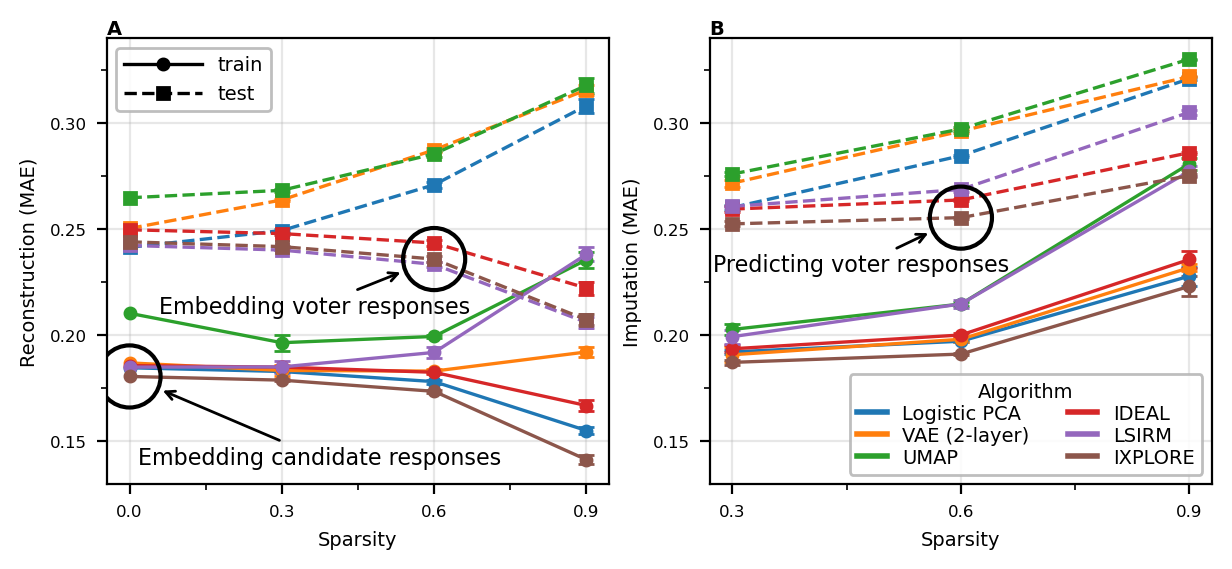

In [5]:
# Value ranges at the three highlighted points, across the shown algorithms.
# Mirrors the highlights in the figure below:
#   1. train  fit_mae    @ sparsity 0.0  — "Embedding candidate responses"
#   2. test   fit_mae    @ sparsity 0.6  — "Embedding user responses"
#   3. test   impute_mae @ sparsity 0.6  — "Predicting user responses"
SUBSET_MODELS = ['pca-logistic', 'vae-2layer', 'umap-logistic', 'ideal', 'lsirm', 'ixplore']

# Train vs. test MAE (fit + impute) for each model
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from src.visualization import figsize

fig, axes = plt.subplots(1, 2, figsize=figsize(width_frac=1.0, aspect=0.45), sharey=True)

for i, model_name in enumerate(SUBSET_MODELS):
    train_sub = train_metrics[train_metrics["model"] == model_name]
    test_sub = test_metrics[test_metrics["model"] == model_name] if not test_metrics.empty else pd.DataFrame()

    t_stats = train_sub.groupby("sparsity").agg(
        fit_mae_mean=("fit_mae", "mean"), fit_mae_std=("fit_mae", "std"),
        impute_mae_mean=("impute_mae", "mean"), impute_mae_std=("impute_mae", "std"),
    ).reset_index()

    color = f"C{i}"
    axes[0].errorbar(t_stats["sparsity"], t_stats["fit_mae_mean"], yerr=t_stats["fit_mae_std"],
                     marker="o", capsize=3, color=color)
    axes[1].errorbar(t_stats["sparsity"], t_stats["impute_mae_mean"], yerr=t_stats["impute_mae_std"],
                     marker="o", capsize=3, color=color)

    if not test_sub.empty:
        te_stats = test_sub.groupby("sparsity").agg(
            fit_mae_mean=("fit_mae", "mean"), fit_mae_std=("fit_mae", "std"),
            impute_mae_mean=("impute_mae", "mean"), impute_mae_std=("impute_mae", "std"),
        ).reset_index()
        axes[0].errorbar(te_stats["sparsity"], te_stats["fit_mae_mean"], yerr=te_stats["fit_mae_std"],
                         marker="s", capsize=3, color=color, linestyle="--")
        axes[1].errorbar(te_stats["sparsity"], te_stats["impute_mae_mean"], yerr=te_stats["impute_mae_std"],
                         marker="s", capsize=3, color=color, linestyle="--")

axes[0].set_ylabel("Reconstruction (MAE)")
axes[1].set_ylabel("Imputation (MAE)")
for ax in axes:
    ax.set_xlabel("Sparsity")
    ax.xaxis.set_major_locator(MultipleLocator(0.3))
    ax.xaxis.set_minor_locator(MultipleLocator(0.15))
    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(MultipleLocator(0.025))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.set_tick_params(labelleft=True)

# Highlight three IXPLORE points with circles + annotations
ixplore_train = train_metrics[train_metrics["model"] == "ixplore"]
ixplore_test = test_metrics[test_metrics["model"] == "ixplore"]

def _point(df, sparsity, col):
    return df[df["sparsity"] == sparsity][col].mean()

# (axis, x, y, text, xytext-offset, ha)
highlights = [
    (axes[0], 0.0, _point(ixplore_train, 0.0, "fit_mae"), "Embedding candidate responses", (3, -25), "left"),
    (axes[0], 0.6, _point(ixplore_test, 0.6, "fit_mae"), "Embedding voter responses", (-43, -13), "center"),
    (axes[1], 0.6, _point(ixplore_test, 0.6, "impute_mae"), "Predicting voter responses", (-36, -13), "center"),
]

for ax, x, y, text, offset, ha in highlights:
    ax.scatter([x], [y], s=500, facecolors="none", edgecolors="black", linewidths=1.5, zorder=5)
    ax.annotate(text, xy=(x, y), xytext=offset, textcoords="offset points",
                fontsize=8, ha=ha, va="top",
                arrowprops=dict(arrowstyle="->", color="black", lw=1,
                                shrinkA=0, shrinkB=13))

style_handles = [
    Line2D([0], [0], color="black", linestyle="-", marker="o", label="train"),
    Line2D([0], [0], color="black", linestyle="--", marker="s", label="test"),
]
axes[0].legend(handles=style_handles, loc="best", handlelength=4)

color_handles = [Line2D([0], [0], color=f"C{i}", lw=2, label=ALGORITHM_LABELS[m]) for i, m in enumerate(SUBSET_MODELS)]
axes[1].legend(handles=color_handles, loc="lower right", title="Algorithm",
               handlelength=1.5, ncols=2, labelspacing=0.15)
fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=axes[0].transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=axes[1].transAxes)
fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.96], w_pad=0.7)
fig.savefig(f"../../figures/baseline_comparison_{DATASET}.pdf")
plt.show()

In [6]:
_highlight_specs = [
    ("Embedding candidate responses", "train", 0.0, "fit_mae"),
    ("Embedding user responses",      "test",  0.6, "fit_mae"),
    ("Predicting user responses",     "test",  0.6, "impute_mae"),
    ("End of train fit_mae", "train", 0.9, "fit_mae"),
    ("End of test fit_mae", "test", 0.9, "fit_mae"),
    ("End of train impute_mae", "train", 0.9, "impute_mae"),
    ("End of test impute_mae", "test", 0.9, "impute_mae"),
]

print(f"Highlight value ranges across {len(SUBSET_MODELS)} shown algorithms "
      f"({', '.join(ALGORITHM_LABELS[m] for m in SUBSET_MODELS)}):\n")


def _per_model_value(df, model_name, sparsity, col):
    """Mean of `col` for one model at one sparsity (matches the plotted point)."""
    sub = df[(df["model"] == model_name) & (df["sparsity"] == sparsity)]
    return np.nan if sub.empty else sub[col].mean()


for label, split, sp, col in _highlight_specs:
    src = train_metrics if split == "train" else test_metrics
    vals = {m: _per_model_value(src, m, sp, col) for m in SUBSET_MODELS}
    present = {m: v for m, v in vals.items() if not np.isnan(v)}
    missing = [ALGORITHM_LABELS[m] for m, v in vals.items() if np.isnan(v)]

    print(f"{label}  [{split} {col} @ sparsity {sp}]")
    if present:
        lo_m = min(present, key=present.get)
        hi_m = max(present, key=present.get)
        print(f"  range: {present[lo_m]:.4f} ({ALGORITHM_LABELS[lo_m]})"
              f"  ->  {present[hi_m]:.4f} ({ALGORITHM_LABELS[hi_m]})")
        # for m in SUBSET_MODELS:
            # if m in present:
                # print(f"    {ALGORITHM_LABELS[m]:<14s} {present[m]:.4f}")
    else:
        print("  (no data)")
    if missing:
        print(f"  missing: {', '.join(missing)}")
    print()


Highlight value ranges across 6 shown algorithms (Logistic PCA, VAE (2-layer), UMAP, IDEAL, LSIRM, IXPLORE):

Embedding candidate responses  [train fit_mae @ sparsity 0.0]
  range: 0.1805 (IXPLORE)  ->  0.2103 (UMAP)

Embedding user responses  [test fit_mae @ sparsity 0.6]
  range: 0.2334 (LSIRM)  ->  0.2874 (VAE (2-layer))

Predicting user responses  [test impute_mae @ sparsity 0.6]
  range: 0.2554 (IXPLORE)  ->  0.2973 (UMAP)

End of train fit_mae  [train fit_mae @ sparsity 0.9]
  range: 0.1412 (IXPLORE)  ->  0.2381 (LSIRM)

End of test fit_mae  [test fit_mae @ sparsity 0.9]
  range: 0.2060 (LSIRM)  ->  0.3178 (UMAP)

End of train impute_mae  [train impute_mae @ sparsity 0.9]
  range: 0.2230 (IXPLORE)  ->  0.2808 (UMAP)

End of test impute_mae  [test impute_mae @ sparsity 0.9]
  range: 0.2752 (IXPLORE)  ->  0.3302 (UMAP)



## Per-Dataset Train|Test Figures

For each dataset, render a 1x2 figure: left panel shows train (x-axis $u$), right panel shows test (x-axis $v$). Within each panel, reconstruction is solid (circles) and imputation is dashed (squares), one color per algorithm. All algorithms are included; missing combinations are skipped silently.

Wrote ../../figures/baseline_train_test_smartvote_2023.pdf


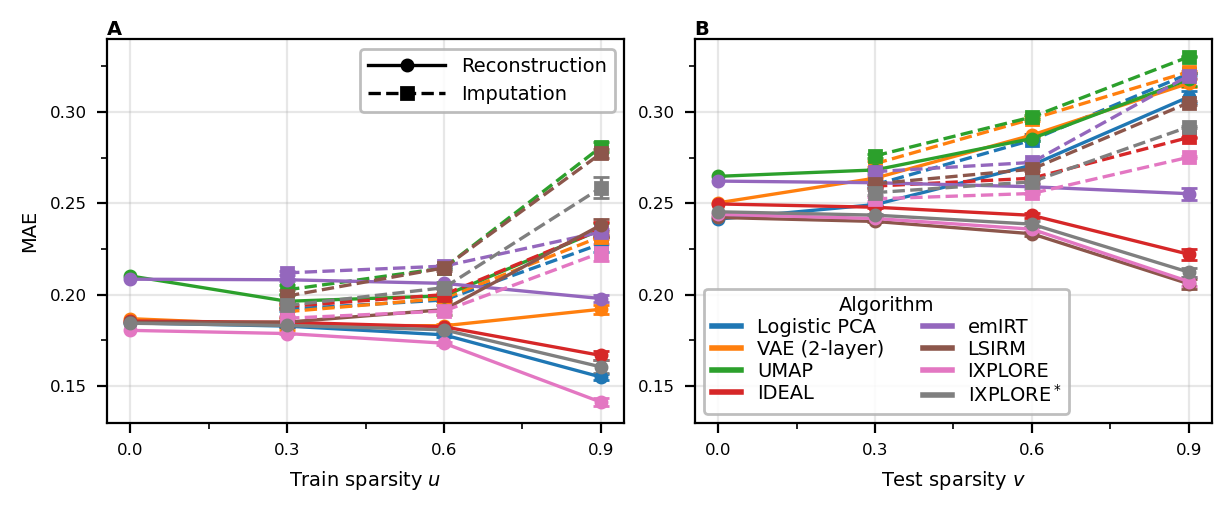

Wrote ../../figures/baseline_train_test_smartvote_2019.pdf


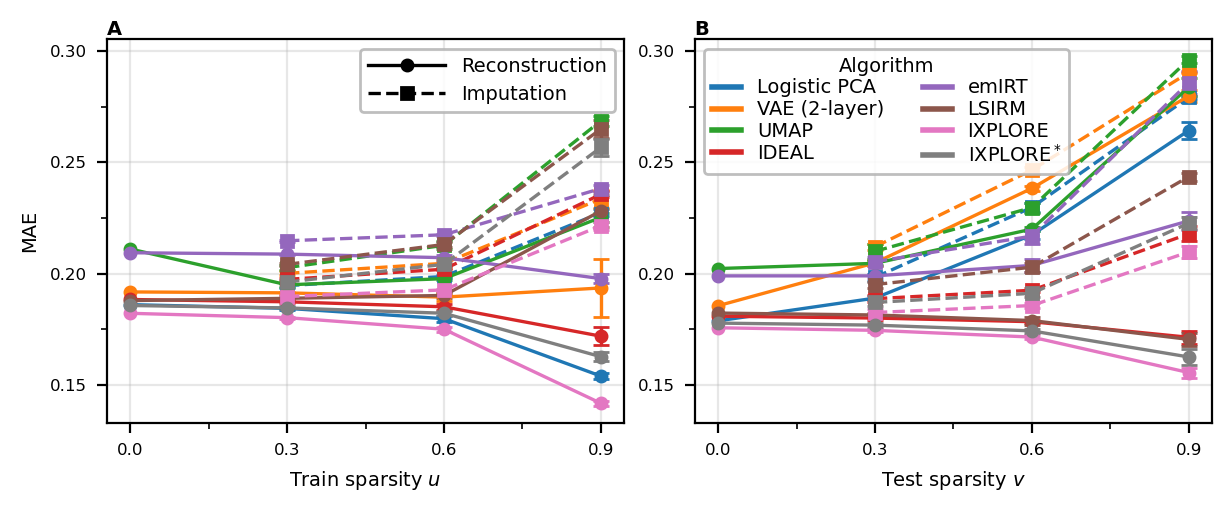

Wrote ../../figures/baseline_train_test_polis.pdf


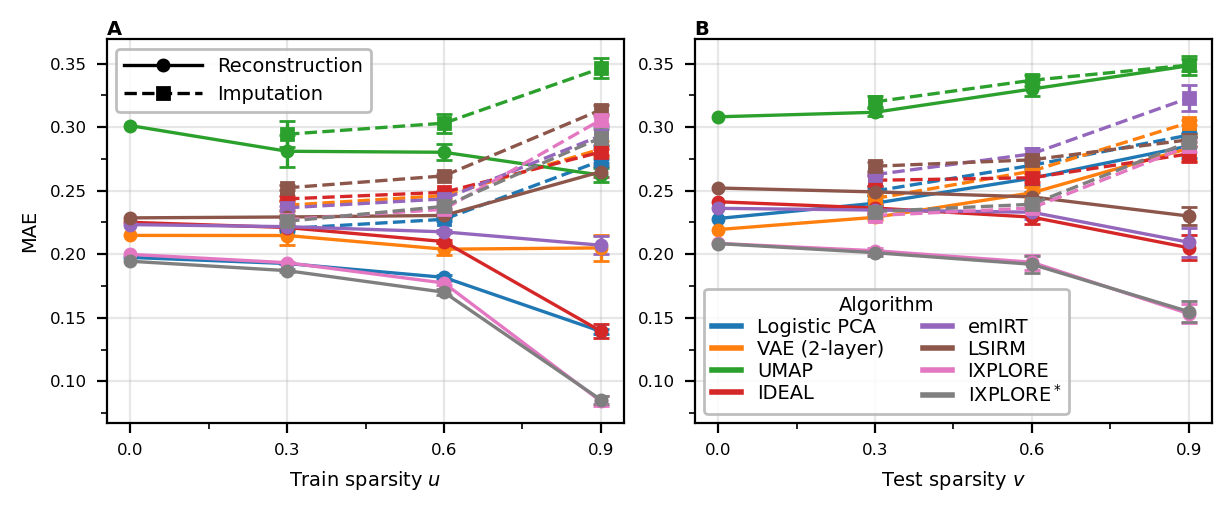

Wrote ../../figures/baseline_train_test_voteview.pdf


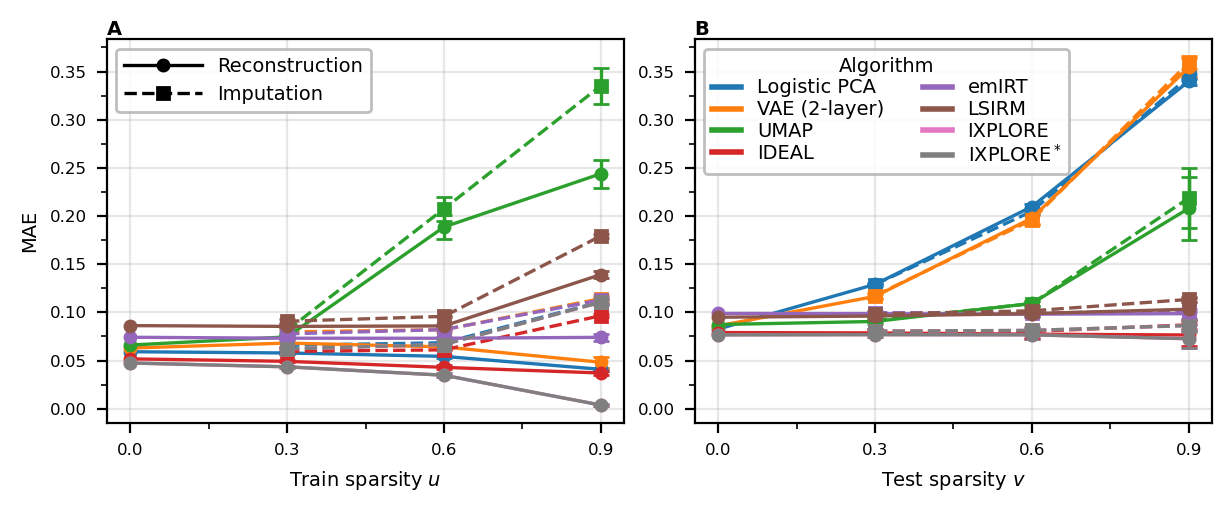

Wrote ../../figures/baseline_train_test_evs.pdf


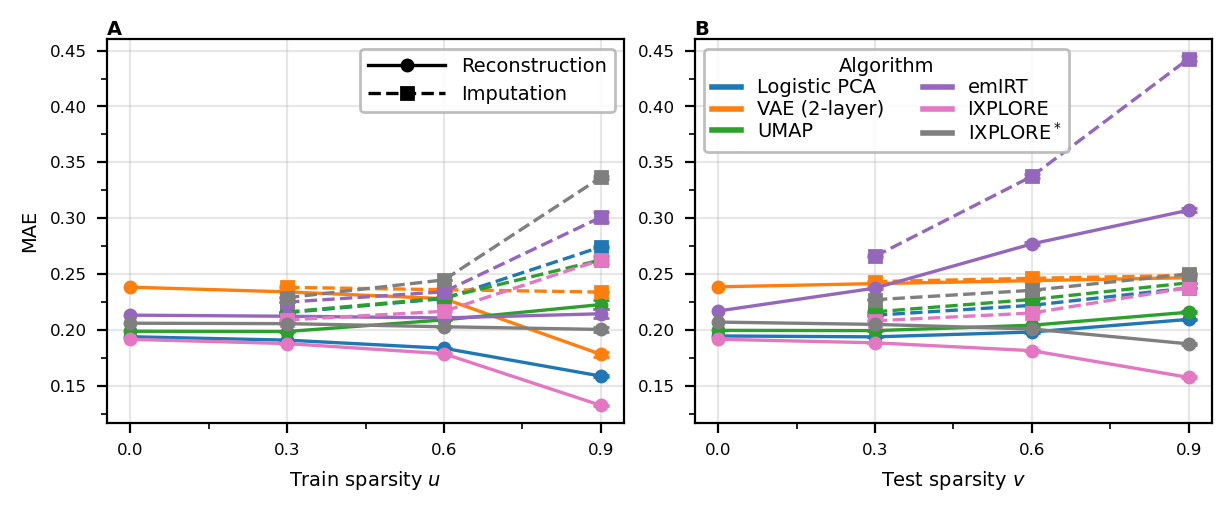

In [7]:
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from src.visualization import figsize

ALG_KEYS = list(ALGORITHMS)
SUBSET_KEYS = ['pca-logistic', 'vae-2layer', 'umap-logistic',
               'ideal', 'emirt', 'lsirm',
               'ixplore', 'ixplore-binarised']


def _load_split(dataset, kind):
    """Return concatenated metrics across ALGORITHMS for one split ('train' or 'test')."""
    base = Path(f"../../results/{dataset}/baseline")
    frames = []
    for alg in ALG_KEYS:
        p = base / alg / f"{kind}_metrics.csv"
        if p.exists():
            frames.append(pd.read_csv(p))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _agg(df, model_name):
    """Return per-sparsity means and stds for fit_mae and impute_mae."""
    sub = df[df["model"] == model_name]
    if sub.empty:
        return None
    return sub.groupby("sparsity").agg(
        fit_mean=("fit_mae", "mean"), fit_std=("fit_mae", "std"),
        imp_mean=("impute_mae", "mean"), imp_std=("impute_mae", "std"),
    ).reset_index()


def make_train_test_figure(dataset, save=True):
    train_df = _load_split(dataset, "train")
    test_df = _load_split(dataset, "test")

    fig, axes = plt.subplots(1, 2, figsize=figsize(width_frac=1.0, aspect=0.4), sharey=True)
    ax_train, ax_test = axes

    for alg in SUBSET_KEYS:
        color = f"C{SUBSET_KEYS.index(alg)}"
        t = _agg(train_df, alg)
        te = _agg(test_df, alg)
        if t is not None:
            ax_train.errorbar(t["sparsity"], t["fit_mean"], yerr=t["fit_std"],
                              marker="o", capsize=3, color=color)
            ax_train.errorbar(t["sparsity"], t["imp_mean"], yerr=t["imp_std"],
                              marker="s", capsize=3, color=color, linestyle="--")
        if te is not None:
            ax_test.errorbar(te["sparsity"], te["fit_mean"], yerr=te["fit_std"],
                             marker="o", capsize=3, color=color)
            ax_test.errorbar(te["sparsity"], te["imp_mean"], yerr=te["imp_std"],
                             marker="s", capsize=3, color=color, linestyle="--")

    ax_train.set_xlabel(r"Train sparsity $u$")
    ax_test.set_xlabel(r"Test sparsity $v$")
    ax_train.set_ylabel("MAE")
    for ax in axes:
        ax.xaxis.set_major_locator(MultipleLocator(0.3))
        ax.xaxis.set_minor_locator(MultipleLocator(0.15))
        ax.yaxis.set_major_locator(MultipleLocator(0.05))
        ax.yaxis.set_minor_locator(MultipleLocator(0.025))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
        ax.yaxis.set_tick_params(labelleft=True)

    style_handles = [
        Line2D([0], [0], color="black", linestyle="-", marker="o", label="Reconstruction"),
        Line2D([0], [0], color="black", linestyle="--", marker="s", label="Imputation"),
    ]
    ax_train.legend(handles=style_handles, loc="best", handlelength=4)

    present_algs = [a for a in SUBSET_KEYS
                    if (_agg(train_df, a) is not None) or (_agg(test_df, a) is not None)]
    color_handles = [Line2D([0], [0], color=f"C{SUBSET_KEYS.index(a)}", lw=2,
                            label=ALGORITHM_LABELS[a]) for a in present_algs]
    ax_test.legend(handles=color_handles, loc="best", title="Algorithm",
                   handlelength=1.5, ncols=2, labelspacing=0.15)

    fig.text(-0, 1, 'A', va='bottom', ha='left', weight='bold', transform=ax_train.transAxes)
    fig.text(-0, 1, 'B', va='bottom', ha='left', weight='bold', transform=ax_test.transAxes)
    fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.96], w_pad=0.7)

    if save:
        out = Path(f"../../figures/baseline_train_test_{dataset}.pdf")
        fig.savefig(out)
        print(f"Wrote {out}")
    plt.show()


for ds_name in DATASETS:
    make_train_test_figure(ds_name)